<a href="https://colab.research.google.com/github/iNuman/PytorchDeepLearnignPlayGround/blob/main/DeepLearningwithPyTorch___GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GradCAM - Gradient Class Activation Map

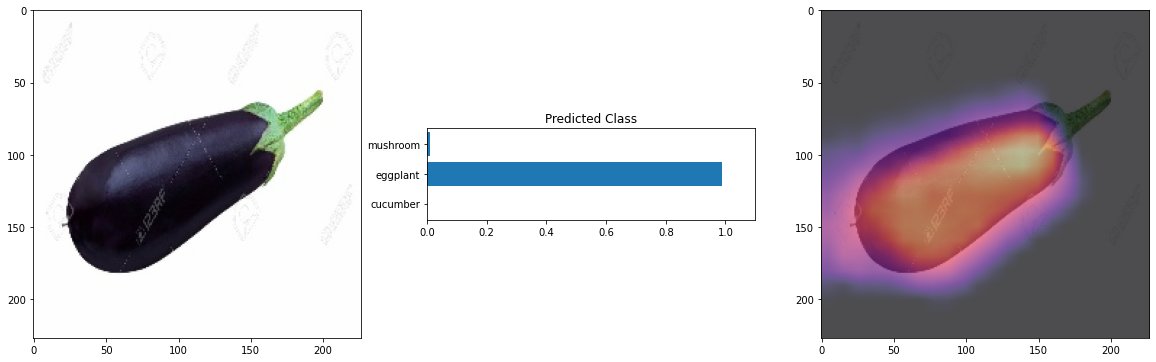

In [132]:
!git clone https://github.com/parth1620/GradCAM-Dataset.git
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

fatal: destination path 'GradCAM-Dataset' already exists and is not an empty directory.
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-csltns2s
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-csltns2s
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Imports

In [133]:
import sys
sys.path.append('/content/GradCAM-Dataset')

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
from torch import nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms as T

from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.nn.modules.pooling import MaxPool2d

import utils

# Configurations

In [135]:
CSV_FILE = '/content/GradCAM-Dataset/train.csv'
DATA_DIR = '/content/GradCAM-Dataset/'

DEVICE = 'cuda'

BATCH_SIZE = 16
LR = 0.001
EPOCHS = 20

In [136]:
data = pd.read_csv(CSV_FILE)
data.head()

,img_path,label
0,train_images/mushroom_51.jpg,2
1,train_images/eggplant_37.jpg,1
2,train_images/mushroom_20.jpg,2
3,train_images/eggplant_51.jpg,1
4,train_images/eggplant_26.jpg,1


In [137]:
# cucumber = 0, eggplant = 1, mushroom = 2

train_df, valid_df = train_test_split(data, test_size=0.2, random_state=42)

# Augmentations

In [138]:
train_augs = A.Compose([
    A.Rotate(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

valid_augs = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Load Image Dataset

In [139]:
trainset = utils.ImageDataset(train_df, augs = train_augs, data_dir = DATA_DIR)
validset = utils.ImageDataset(valid_df, augs = valid_augs, data_dir = DATA_DIR)

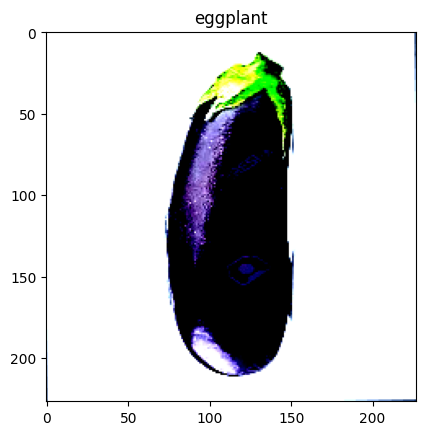

In [140]:
image_label = trainset[0] # Get the image and label as a single item

if image_label is not None:
    image, label = image_label # Unpack only if the item is not None
    # the image will be in the form of
    #  pythorch channel c, height h and width w
    # so whenever we're plotting we need to convert it to
    #  (c, h, w) -> (h, w,c)
    class_list = ['cucumber', 'eggplant', 'mushroom']
    plt.imshow(image.permute(1, 2, 0))
    plt.title(class_list[label]);
else:
    print("Could not load the first image.")

In [141]:
print(f"No. of examples in the {len(trainset)}")
print(f"No. of examples in the {len(validset)}")

No. of examples in the 148
No. of examples in the 38


# Load Dataset into Batches

In [142]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)

In [143]:
print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 10
No. of batches in validloader : 3


In [144]:
for images, labels in trainloader:
  break
print(f"One batch image shape : {images.shape}")
print(f"One batch label shape : {labels.shape}")
# this means we will be having 16 images in one batch with channel 3, and size 227

One batch image shape : torch.Size([16, 3, 227, 227])
One batch label shape : torch.Size([16])


# Create Model

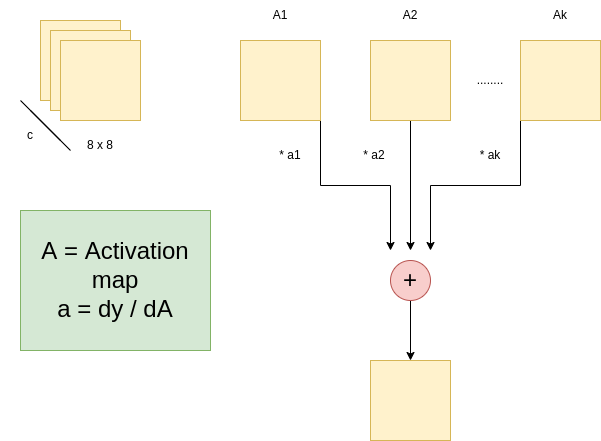

In [145]:
class ImageModel(nn.Module):
    def __init__(self):
        super(ImageModel, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(5, 5), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 4), stride=2),

            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=(5, 5), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 4), stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(5, 5), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(4, 4), stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(5, 5), padding=1),
            nn.ReLU(),
        )

        # You may not need this additional maxpool layer
        self.maxpool = nn.MaxPool2d(kernel_size=(4, 4), stride=2)

        # Ensure the flattened size matches the output of the feature extractor
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6400, 2048),  # Ensure this matches the flattened size
            nn.ReLU(),
            nn.Linear(2048, 3)
        )

        self.gradient = None

    def activations_hook(self, grad):
        self.gradient = grad

    def forward(self, images):
        x = self.feature_extractor(images)
        # print("Output shape after feature extractor:", x.shape)  # Print the shape
        h = x.register_hook(self.activations_hook)

        # If you keep the maxpool layer, uncomment the following line
        x = self.maxpool(x)

        x = self.classifier(x)
        return x

    def get_activation_gradient(self):
        return self.gradient

    def get_activation(self, x):
        return self.feature_extractor(x)

In [146]:
model = ImageModel()
model.to(DEVICE)

ImageModel(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(4, 4), stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(4, 4), stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(4, 4), stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
  )
  (maxpool): MaxPool2d(kernel_size=(4, 4), stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6400, out_features=2048, bias=True)
    (2): ReLU()
    (3): Linear(in_features=2048, out_features=3, bias=True)
  )
)

In [147]:
# # Example usage
# # Assuming you have already defined your model
# model = ImageModel()

# # Get one batch from the trainloader
# for images, labels in trainloader:
#     break

# # Pass the images through the model to check the output shape
# output = model(images)
# print(f"Output shape from the model: {output.shape}")

# Create Train and Eval function

In [148]:
def train_fn(dataloader, model, optimizer, criterion):
  model.train()
  total_loss = 0.0
  for images, labels in tqdm(dataloader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    optimizer.zero_grad()

    # as you can see In our neural network above we havent use any sigmoid or softmax
    # activation layer and we're getting logits that are the
    # outputs without any softmax or sigmoid activation layer this
    # is because
    # the loss function we'll be using is Cross entropy loss
    # and in pytorch Cross entropy loss the inputs are
    # logits and true labels

    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step() # this will update the weights and biases of hyper parameters

    total_loss += loss.item()

  return total_loss / len(dataloader) # avg loss

In [149]:
def eval_fn(dataloader, model, criterion):
  model.eval()
  total_loss = 0.0
  for images, labels in tqdm(dataloader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    # as you can see In our neural network above we havent use any sigmoid or softmax
    # activation layer and we're getting logits that are the
    # outputs without any softmax or sigmoid activation layer this
    # is because
    # the loss function we'll be using is Cross entropy loss
    # and in pytorch Cross entropy loss the inputs are
    # logits and true labels

    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()

    total_loss += loss.item()

  return total_loss / len(dataloader) # avg loss

# Training Loop

In [150]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)
criterion = torch.nn.CrossEntropyLoss()

In [151]:
best_valid_loss  = np.inf

for i in range(EPOCHS):

  train_loss = train_fn(trainloader, model, optimizer, criterion)
  valid_loss = eval_fn(validloader, model, criterion)

  if valid_loss < best_valid_loss:
    torch.save(model.state_dict(), "best_weights.pt")
    best_valid_loss = valid_loss
    print("Saved best loss")

  print(f"Epoch : {i + 1} Train loss : {train_loss} Valid loss : {valid_loss}")

100%|██████████| 3/3 [00:00<00:00, 27.21it/s]


Saved best loss
Epoch : 1 Train loss : 1.1228832364082337 Valid loss : 0.6808174649874369


100%|██████████| 3/3 [00:00<00:00, 34.16it/s]


Saved best loss
Epoch : 2 Train loss : 0.543236130475998 Valid loss : 0.36294972399870556


100%|██████████| 3/3 [00:00<00:00, 32.22it/s]


...

Saved best loss
Epoch : 18 Train loss : 0.13643735419027508 Valid loss : 0.04722572614749273


100%|██████████| 3/3 [00:00<00:00, 22.27it/s]


Epoch : 19 Train loss : 0.08307909406721592 Valid loss : 0.330458019549648


100%|██████████| 3/3 [00:00<00:00, 13.90it/s]

Epoch : 20 Train loss : 0.158699150942266 Valid loss : 0.1206281017512083


# Get GradCAM

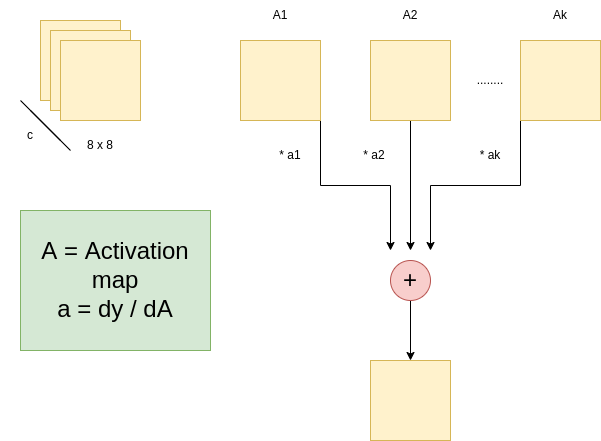

In [152]:
def get_gradcam(model, image, label, size):

  label.backward()
  gradients = model.get_activation_gradient()
  pooled_gradients = torch.mean(gradients, dim = [0, 2, 3]) # a1, a2,..ak
  activations = model.get_activation(image).detach() # A1, A2...Ak

  for i in range(activations.shape[1]):
    activations[:, i, :, :] *= pooled_gradients[i]

  heatmap = torch.mean(activations, dim = 1).squeeze().cpu()
  heatmap = nn.ReLU()(heatmap)
  heatmap /= torch.max(heatmap)

  heatmap = cv2.resize(heatmap.numpy(), (size, size))

  return heatmap

In [153]:
# cucumber = 0, eggplant = 1, mushroom = 2

/tmp/ipython-input-1301436655.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denorm_image = image.permute(1, 2, 0) * np.array((0.229,0.224, 0.225)) + np.array((0.485, 0.456, 0.406))


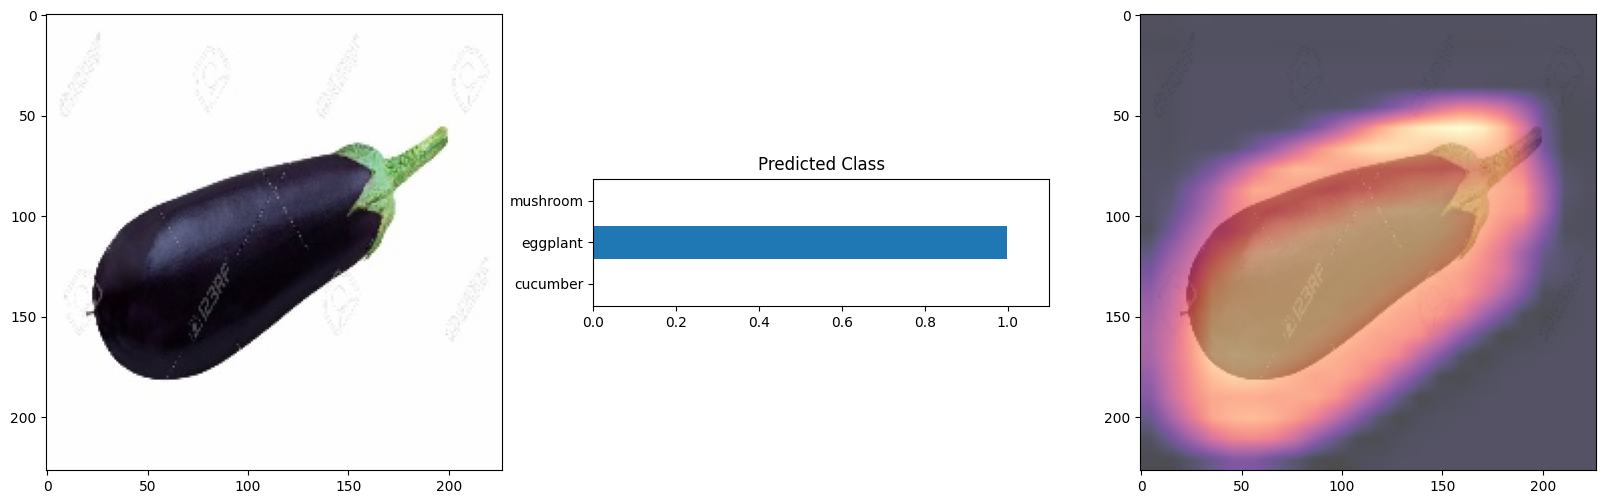

In [154]:
image, label = validset[4] # Access item using square brackets
denorm_image = image.permute(1, 2, 0) * np.array((0.229,0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
image = image.unsqueeze(0).to(DEVICE)

pred = model(image)
heatmap = get_gradcam(model, image, pred[0][label], size = 227)
utils.plot_heatmap(denorm_image, pred, heatmap)